# Using the MNIST dataset with Kosh

In [1]:
import os
import kosh

# Make sure local file is new sql file
kosh_example_sql_file = "kosh_mnist_example.sql"
if os.path.exists(kosh_example_sql_file):
    os.remove(kosh_example_sql_file)
    
# Create db
kosh.create_new_db(kosh_example_sql_file)

In [2]:
from  kosh import KoshStore, KoshLoader
import os

# connect to store
store = KoshStore(engine="sina", username=os.environ["USER"], sql='sql', db_path=kosh_example_sql_file)

In [3]:
# Add MNST datasets to store
train = store.create(name="train10k", metadata={'project':"MNIST"})
test = store.create(name="test", metadata={'project':"MNIST"})


In [4]:
# Associate files with datasets
train.add_file("../../pytorch_examples/data/raw/t10k-images-idx3-ubyte", mime_type="mnist")
test.add_file("../../pytorch_examples/data/raw/t10k-images-idx3-ubyte", mime_type="mnist")

In [6]:
import struct
import numpy
import torch
from torch.utils.data import Dataset

def load_from_mnst(uri, index):
    with open(uri, "rb") as f:
        magic, nitems = struct.unpack(">2i", f.read(8))
        if magic == 2051:
            rows, columns = struct.unpack(">ii", f.read(8))
            #print(rows, columns)
            item_size = rows*columns
        else:
            item_size = 1
        offset = item_size*index
        f.seek(offset, 1)
        data = struct.unpack(">{}b".format(item_size), f.read(item_size))
        if magic == 2051:
            data = numpy.array(data)+128
            data.shape = (rows, columns)
    return data

class MNSTDataset(Dataset):
    def __init__(self, uri, transform=None):
        self.uri = uri

    def __len__(self):
        with open(self.uri, "rb") as f:
            magic, nitems = struct.unpack(">2i", f.read(8))
        return nitems
        
    def __getitem__(self, key):
        if torch.is_tensor(key):
            key = key.tolist()

        data = load_from_mnst(self.uri, key)
        lbl = self.uri.replace("image", "label").replace("idx3", "idx1")
        if os.path.exists(lbl):
            lbl = load_from_mnst(lbl, key)
        else:
            lbl = None
        return data, lbl

    def __get_slice__(self, start, end):
        out = []
        for i in range(start, end):
            out.append(self[i])
        return out




class MNSTLoader(KoshLoader):
    def __init__(self, obj):
        super(MNSTLoader, self).__init__(obj, {"mnist": ["numpy", ]})

    def open(self, mode='r'):
        return MNSTFeature(self.obj.uri)

    def get(self, feature, *args, **kargs):
        self.open()[feature]
        
    def list_features(self):
        with open(self.obj.uri, "rb") as f:
            magic = struct.unpack(">i", f.read(4))[0]
        if magic == 2051:
            return ["image", ]
        else:
            return ["label", ]

store.add_loader(MNSTLoader)

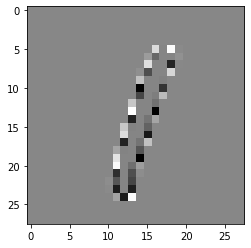

In [7]:
mnst = train_img.get("image")
indx = 5
img, lbl = feature[indx]
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(img, cmap="gray")
train_img.open()

In [8]:
from torch.utils.data import DataLoader

dataloader = DataLoader(train_img.open(), batch_size=4,
                        shuffle=True, num_workers=4)



In [15]:
# Stolen from pytorch example mnist
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


use_cuda = False
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 20, 5, 1)
        self.conv2 = nn.Conv2d(20, 50, 5, 1)
        self.fc1 = nn.Linear(4*4*50, 500)
        self.fc2 = nn.Linear(500, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        x = x.view(-1, 4*4*50)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

    
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

device = torch.device("cuda" if use_cuda else "cpu")

model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=.5)
epochs = 10
for epoch in range(1, epochs + 1):
    train(model, device, dataloader, optimizer, epoch)
    #test(args, model, device, test_loader)



ValueError: too many values to unpack (expected 2)